In [9]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

In [10]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [11]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [12]:
inconsitencies_dict = {}

for publisher, journals in processed_data.items():
    n_question = 0
    inconsitencies = {"Consistent": 0, "Inconsistent": 0}

    for journal, data in journals.items():
        for question, answer in data.items():
            n_question += 1

            if question == "data_recommended" or question == "data_required":
                continue

            if not answer.has_multiple_answers():
                continue

            if answer.has_discrepancies():
                inconsitencies["Inconsistent"] += 1
            else:
                inconsitencies["Consistent"] += 1
    
    print(publisher, inconsitencies)
    inconsitencies_dict[publisher] = inconsitencies

ACS {'Consistent': 147, 'Inconsistent': 57}
AIP {'Consistent': 215, 'Inconsistent': 23}
APS {'Consistent': 183, 'Inconsistent': 4}
Bentham Science {'Consistent': 72, 'Inconsistent': 30}
Elsevier {'Consistent': 88, 'Inconsistent': 31}
Frontiers {'Consistent': 63, 'Inconsistent': 56}
IEEE {'Consistent': 225, 'Inconsistent': 30}
IOP {'Consistent': 139, 'Inconsistent': 14}
MDPI {'Consistent': 140, 'Inconsistent': 115}
Optica {'Consistent': 75, 'Inconsistent': 10}
Pleiades Publishing {'Consistent': 102, 'Inconsistent': 51}
RSC {'Consistent': 106, 'Inconsistent': 47}
Springer Nature {'Consistent': 116, 'Inconsistent': 54}
Taylor & Francis {'Consistent': 227, 'Inconsistent': 28}
Wiley {'Consistent': 167, 'Inconsistent': 88}
codata {'Consistent': 14, 'Inconsistent': 3}
open journals {'Consistent': 8, 'Inconsistent': 9}


In [13]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats
import numpy as np

inconsitency_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    inconsitency_list_0 = []
    score_list_0 = []

    for journal, journal_results in publisher_results.items():
        score = get_journal_score(journal_results)
        score_list_0.append(score)

    inconsitency = inconsitencies_dict[publisher]["Consistent"] / (inconsitencies_dict[publisher]["Consistent"] + inconsitencies_dict[publisher]["Inconsistent"])
    inconsitency_list.append(inconsitency)
    score_list.append( np.mean(score_list_0) )
            
# Pearson correlation coefficient
r, p_value = stats.pearsonr(inconsitency_list, score_list)
print(f"n {len(inconsitency_list)} Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

n 17 Pearson correlation: r = -0.615, p = 0.9 %


In [14]:
df = pd.DataFrame({
    'Inconsitency': inconsitency_list,
    'Open data score': score_list
})

# Write the DataFrame to a CSV file
df.to_csv('../../data/processed/policy_vs_consitency.csv', index=False)

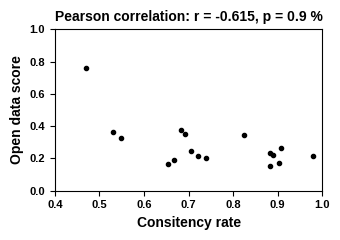

In [15]:
fig = plt.figure(figsize=(3.5, 2.5))

plt.plot(inconsitency_list, score_list, ".k")
plt.title(f"Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")
plt.xlabel("Consitency rate")
plt.ylabel("Open data score")
plt.xlim((0.4, 1.0))
plt.ylim((0.0, 1.0))
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_consitency.pdf")

In [16]:
#remove outliers and recalculate Pearson correlation coefficient
inconsitency_list_filtered = []
score_list_filtered = []
for inconsitency, score in zip(inconsitency_list, score_list):
    if score < 0.75:  # Example threshold to remove outliers
        inconsitency_list_filtered.append(inconsitency)
        score_list_filtered.append(score)
r, p_value = stats.pearsonr(inconsitency_list_filtered, score_list_filtered)
print(f"After removing outliers: Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

After removing outliers: Pearson correlation: r = -0.455, p = 7.6 %
